<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F08_multi_engine_master_workflow.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 08 · The 4-Family Parallel Master Workflow: Multi-Engine DAG & Stacking Ensembles

This notebook demonstrates the flagship architecture of `scale-forecasting`: a **single `RunConfig`** that routes all **4 model families in parallel** across their optimal cloud runtimes (`dag.py` & `router.py` — mixing `spark`, `vertex`, `gce`, `gke`, `ray`, and `bigquery`, or running all Python families on a single shared `gke` cluster with dedicated CPU and GPU node pools), tears down each family's compute the instant it finishes (**zero-idle per-family compute**), and joins all families in a downstream **stacked ensemble stage**.

```mermaid
flowchart LR
    CFG["Single RunConfig<br/>1 Deterministic run_id"] --> DAG["dag.plan_dag()<br/>Per-Family Parallel Router"]
    subgraph Parallel["Concurrent Family Execution (Zero-Idle Compute)"]
        F1["statistical<br/>theta · autoets<br/>(Spark, Vertex, GCE, or GKE CPU)"]
        F2["ml<br/>lightgbm · xgboost<br/>(Vertex or GKE CPU · Global Mode)"]
        F3["deep_learning<br/>neuralprophet<br/>(Vertex, GKE, or Ray GPU)"]
        F4["native<br/>arima_plus · timesfm<br/>(BigQuery Serverless SQL)"]
    end
    DAG --> F1 & F2 & F3 & F4 --> ENS["ensemble Stage<br/>inverse_error · nnls · ridge"]
    ENS --> LB["v_model_leaderboard<br/>All 4 Families + Ensembles"]
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 2 · Configure the 4-Family Master DAG & Inspect `forecaster.explain()`

Look at how `forecaster.explain()` decomposes our single `RunConfig` into independent family execution rows, each with its own runtime (`spark`, `vertex`, `gce`, `gke`, `ray`, or `bigquery`), training mode (`local` vs. `global`), hardware (`cpu` vs. `gpu`), and sizing. *(When routing families to `runtime='gke'`, `shared_clusters.py` provisions a single shared GKE cluster with fit-for-purpose CPU and GPU node pools per family and scales down individual GPU nodes as each `deep_learning` model pod finishes.)*

In [3]:
import time
from scale_forecasting import Forecaster, RunConfig

# === Parameters — edit me ===============================================
RUN_NAME = f"nb08 master workflow {int(time.time())}"
SOURCE_TABLE = "source_series_iceberg"
MODELS = ["theta", "holtwinters", "lightgbm", "xgboost", "tide", "arima_plus", "timesfm"]
HORIZON = 28
SERIES_LIMIT = 15
N_FOLDS = 2
ENSEMBLE_STRATEGIES = ["mean", "inverse_error", "nnls", "ridge"]
# ========================================================================

cfg = RunConfig(
    run_name=RUN_NAME,
    python_runtime="spark",
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=MODELS,
    model_params={
        "tide": {"training_mode": "global", "max_epochs": 15},
    },
    compute={
        "families": {
            "statistical": {"runtime": "spark"},
            "ml": {"runtime": "vertex", "machine_type": "n2-standard-4", "workers": 1},
            "deep_learning": {"runtime": "vertex", "hardware": "cpu", "machine_type": "n2-standard-4", "workers": 1},
        }
    },
    features={"holidays": ["US"]},
    backtest={"enabled": True, "n_folds": N_FOLDS, "horizon": HORIZON, "step": HORIZON},
    ensemble={"enabled": True, "strategies": ENSEMBLE_STRATEGIES},
)

forecaster = Forecaster(cfg, settings=settings)
print("Master run_id:", forecaster.run_id)
display(forecaster.explain())

# Also inspect the DAG node topology directly via forecaster.dag()
for node in forecaster.dag():
    print(f"  DAG node: {node.family:<15} runtime={node.runtime:<10} hardware={str(node.hardware):<5} models={list(node.models)} depends_on={list(node.depends_on)}")

Master run_id: nb08-master-workflow-1791145853-afcf6015f8ee


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb08-master-workflow-1791145853-afcf6015f8ee,statistical,sf-nb08-master-workflow-1791145853-afcf6015f8e...,spark,None,NaN,cpu,None,"theta, holtwinters","theta:local, holtwinters:local",15,2,30,none,
1,nb08-master-workflow-1791145853-afcf6015f8ee,ml,sf-nb08-master-workflow-1791145853-afcf6015f8e...,vertex,n2-standard-4,1.0,cpu,None,"lightgbm, xgboost","lightgbm:local, xgboost:local",15,2,30,none,
2,nb08-master-workflow-1791145853-afcf6015f8ee,deep_learning,sf-nb08-master-workflow-1791145853-afcf6015f8e...,vertex,n2-standard-4,1.0,cpu,None,tide,tide:global,15,2,15,none,
3,nb08-master-workflow-1791145853-afcf6015f8ee,native,sf-nb08-master-workflow-1791145853-afcf6015f8e...,bigquery,sql,1.0,sql,None,"arima_plus, timesfm","arima_plus:local, timesfm:local",15,2,30,none,
4,nb08-master-workflow-1791145853-afcf6015f8ee,ensemble,sf-nb08-master-workflow-1791145853-afcf6015f8e...,bigquery,sql,1.0,sql,None,"ensemble_mean, ensemble_inverse_error, ensembl...",barrier,15,2,60,none,sf-nb08-master-workflow-1791145853-afcf6015f8e...


  DAG node: statistical     runtime=spark      hardware=cpu   models=['theta', 'holtwinters'] depends_on=[]
  DAG node: ml              runtime=vertex     hardware=cpu   models=['lightgbm', 'xgboost'] depends_on=[]
  DAG node: deep_learning   runtime=vertex     hardware=cpu   models=['tide'] depends_on=[]
  DAG node: native          runtime=bigquery   hardware=None  models=['arima_plus', 'timesfm'] depends_on=[]
  DAG node: ensemble        runtime=bigquery   hardware=None  models=[] depends_on=['sf-nb08-master-workflow-1791145853-afcf6015f8ee-statistical-a1', 'sf-nb08-master-workflow-1791145853-afcf6015f8ee-ml-a1', 'sf-nb08-master-workflow-1791145853-afcf6015f8ee-deep_learning-a1', 'sf-nb08-master-workflow-1791145853-afcf6015f8ee-native-a1']


## Act 3 · Launch & Monitor All Families Concurrently (`forecaster.run_live()`)

`forecaster.run_live()` launches the parallel family threads, displays real-time per-family progress bars, escalates to live platform probes (`probe=True`) if any engine is quiet for >300s, and runs the final ensemble join.

Master workflow nb08-master-workflow-1791145853-afcf6015f8ee finished: status=COMPLETED, wall_clock=1530.0s


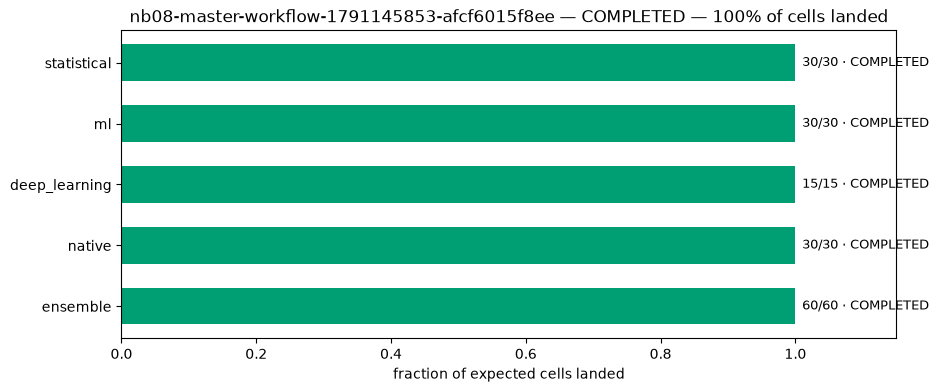

In [4]:
result = forecaster.run_live(poll_s=15.0, probe=True)
print(f"Master workflow {result.run_id} finished: status={result.status}, wall_clock={result.runtime_seconds:.1f}s")

## Act 4 · Comprehensive Post-Run Review (Leaderboard, Cohorts, Calibration, Ensemble Weights, Forecast Decomposition & Gantt Trace)

Let's run the complete diagnostic suite across all 4 model families and the stacked ensembles:
1. `leaderboard_df()`, `plot_leaderboard()`, and `plot_metric_distribution()`
2. `cohorts_df()` and `jobs_df()`
3. `plot_calibration()` and `plot_ensemble_weights()`
4. `plot_forecasts()`, `plot_forecast_explanation()`, and `plot_trace()`

,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,arima_plus,native,False,None,bigquery,15,wape,0.358122,0.116795,...,10.926623,15.050516,0.592857,57.506210,NaN,NaN,1.0,420,NaN,NaN
1,2,timesfm,native,False,None,bigquery,15,wape,0.361305,0.114332,...,11.005670,15.294330,0.761905,50.668533,NaN,NaN,1.0,420,NaN,NaN
2,3,ensemble_nnls,ensemble,True,b5d76d4b5342,ensemble,15,wape,0.369138,0.116933,...,10.916653,14.945209,NaN,NaN,NaN,NaN,0.0,420,-0.011017,-0.030762
3,4,ensemble_ridge,ensemble,True,b5d76d4b5342,ensemble,15,wape,0.374555,0.119219,...,11.048510,15.078644,NaN,NaN,NaN,NaN,0.0,420,-0.016433,-0.045888
4,5,ensemble_inverse_error,ensemble,True,b5d76d4b5342,ensemble,15,wape,0.382596,0.117985,...,11.058126,14.979410,NaN,NaN,NaN,NaN,1.0,420,-0.024474,-0.068340
5,6,holtwinters,statistical,False,None,spark,15,wape,0.387183,0.135680,...,12.934460,17.531664,0.698810,65.546850,1.790269,0.916797,1.0,420,NaN,NaN
6,7,ensemble_mean,ensemble,True,b5d76d4b5342,ensemble,15,wape,0.397225,0.125386,...,12.119268,16.220111,NaN,NaN,NaN,NaN,1.0,420,-0.039104,-0.109191
7,8,lightgbm,ml,False,None,spark,15,wape,0.441840,0.151010,...,13.821479,18.199157,0.282143,99.018758,5.173817,3.124841,1.0,420,NaN,NaN
8,9,theta,statistical,False,None,spark,15,wape,0.443389,0.158292,...,14.614160,18.970049,0.995238,262.555296,2.469126,1.106682,1.0,420,NaN,NaN
9,10,xgboost,ml,False,None,spark,15,wape,0.448197,0.139390,...,14.319092,19.378332,0.210714,116.923408,5.526655,6.022588,1.0,420,NaN,NaN


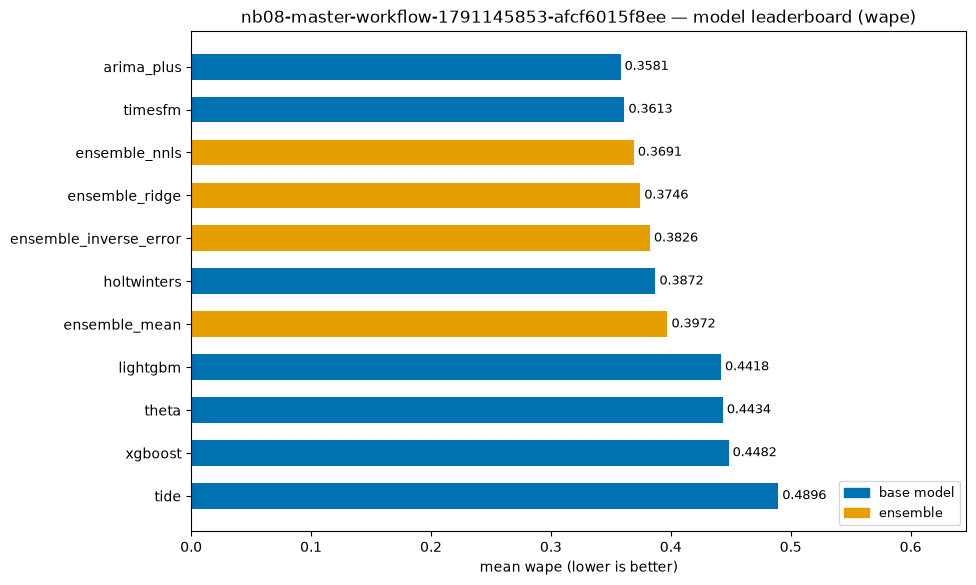

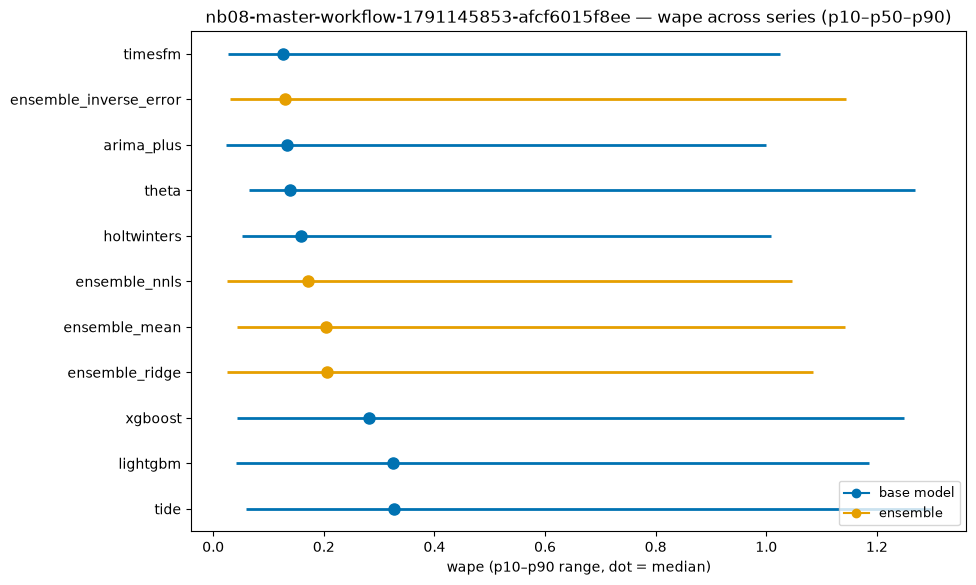

,model_type,family,is_ensemble,n_series,score,pooled_wape,n_comparable_series,n_full,n_reduced,n_unscored,n_failed,n_not_requested,fold_histogram,refit_modes,staleness_gap
0,arima_plus,native,False,15,0.358122,0.116795,15,15,0,0,0,0,2f:15,per_fold:15,None
1,timesfm,native,False,15,0.361305,0.114332,15,15,0,0,0,0,2f:15,per_fold:15,None
2,ensemble_nnls,ensemble,True,15,0.369138,0.116933,15,0,0,0,0,15,none,per_fold:15,None
3,ensemble_ridge,ensemble,True,15,0.374555,0.119219,15,0,0,0,0,15,none,per_fold:15,None
4,ensemble_inverse_error,ensemble,True,15,0.382596,0.117985,15,0,0,0,0,15,none,per_fold:15,None
5,holtwinters,statistical,False,15,0.387183,0.135680,15,15,0,0,0,0,2f:15,per_fold:15,None
6,ensemble_mean,ensemble,True,15,0.397225,0.125386,15,0,0,0,0,15,none,per_fold:15,None
7,lightgbm,ml,False,15,0.441840,0.151010,15,15,0,0,0,0,2f:15,per_fold:15,None
8,theta,statistical,False,15,0.443389,0.158292,15,15,0,0,0,0,2f:15,per_fold:15,None
9,xgboost,ml,False,15,0.448197,0.139390,15,15,0,0,0,0,2f:15,per_fold:15,None


,family,job_key,system_job_id,runtime,status,attempt,hardware,gpu_type,spark_mode,runtime_seconds
0,deep_learning,sf-nb08-master-workflow-1791145853-afcf6015f8e...,projects/307701787156/locations/us-central1/cu...,vertex,COMPLETED,1,cpu,None,None,383.735770
1,ensemble,sf-nb08-master-workflow-1791145853-afcf6015f8e...,sf-nb08-master-workflow-1791145853-afcf6015f8e...,bigquery,COMPLETED,1,None,None,None,14.836364
2,ml,sf-nb08-master-workflow-1791145853-afcf6015f8e...,projects/307701787156/locations/us-central1/cu...,vertex,COMPLETED,1,cpu,None,None,369.269347
3,native,sf-nb08-master-workflow-1791145853-afcf6015f8e...,sf-nb08-master-workflow-1791145853-afcf6015f8e...,bigquery,COMPLETED,1,None,None,None,74.923445
4,statistical,sf-nb08-master-workflow-1791145853-afcf6015f8e...,sf-nb08-master-workflow-1791145853-afcf6015f8e...,spark,COMPLETED,1,cpu,None,serverless,1467.059919


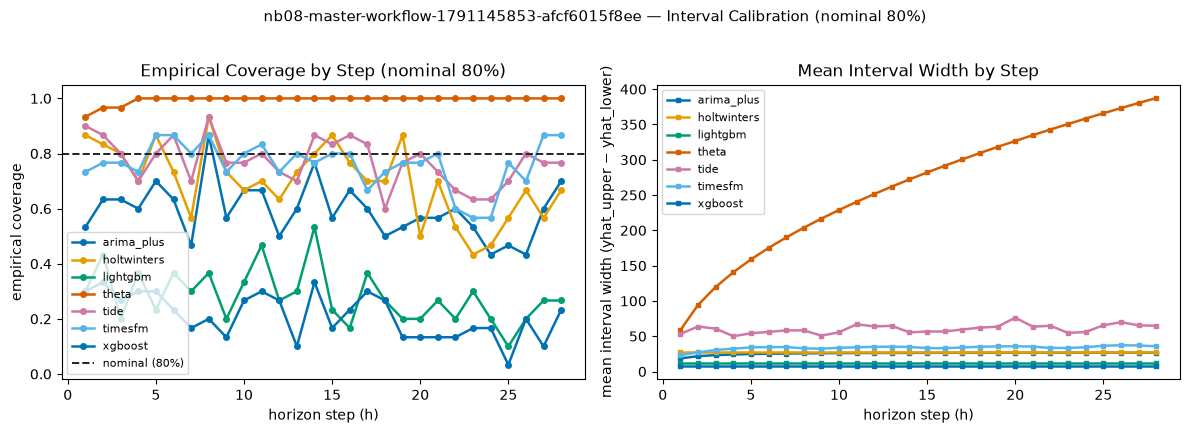

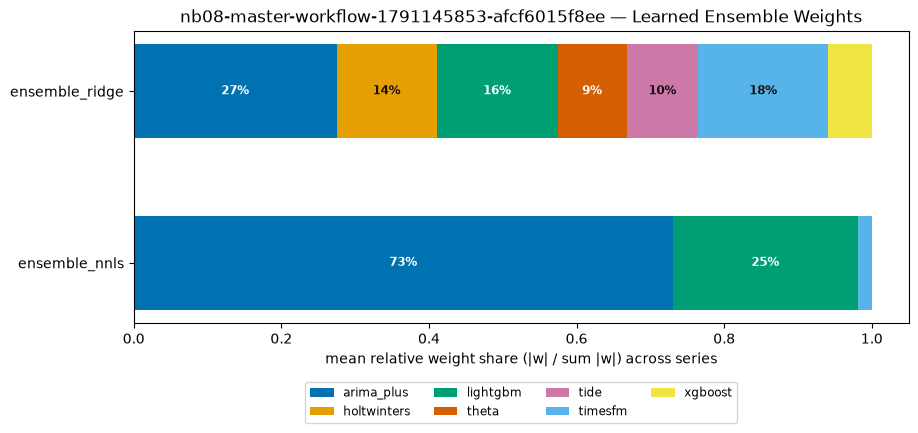

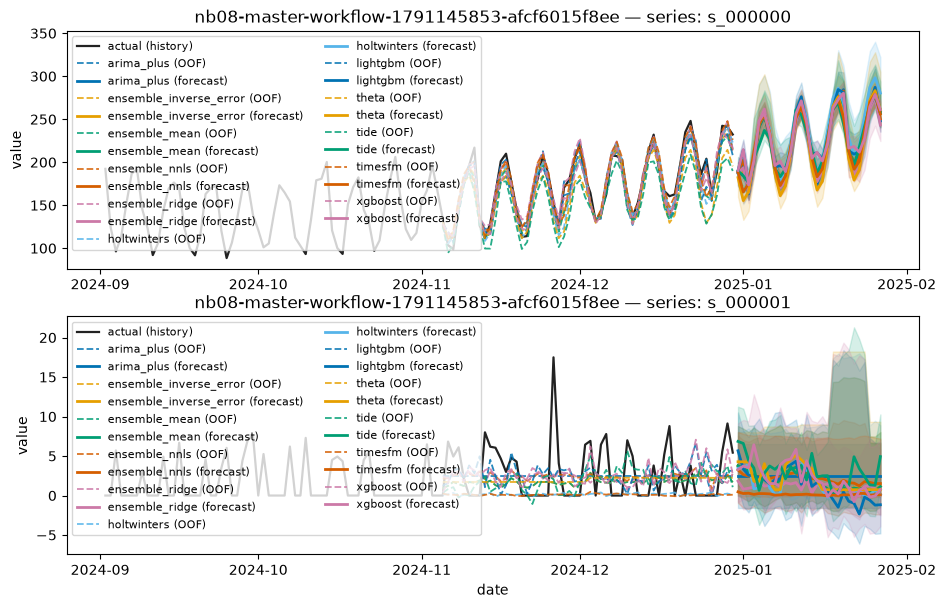

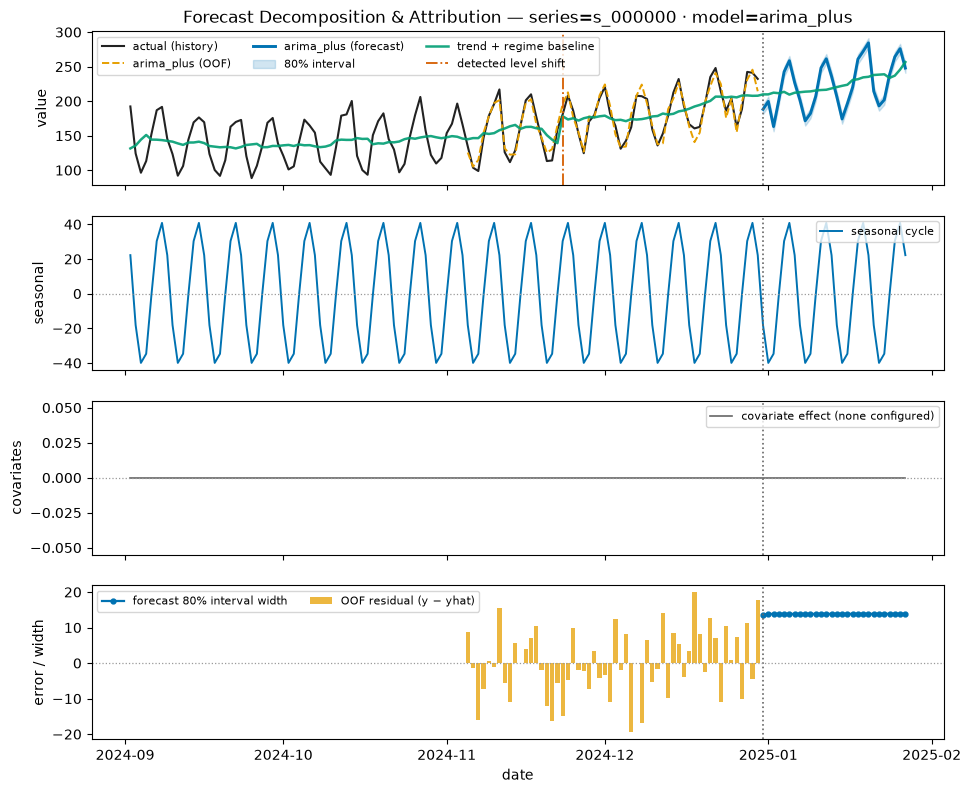

,kind,lane,label,start,end,duration_s,status,runtime,model_type,ts_id
0,job,deep_learning,deep_learning,2026-10-04 20:31:16.882802+00:00,2026-10-04 20:37:43.577675+00:00,386.694873,COMPLETED,vertex,None,None
1,job,ensemble,ensemble,2026-10-04 20:55:52.137575+00:00,2026-10-04 20:56:09.297731+00:00,17.160156,COMPLETED,bigquery,None,None
2,job,ml,ml,2026-10-04 20:31:16.951681+00:00,2026-10-04 20:37:29.080684+00:00,372.129003,COMPLETED,vertex,None,None
3,job,native,native,2026-10-04 20:31:16.835748+00:00,2026-10-04 20:32:51.708772+00:00,94.873024,COMPLETED,bigquery,None,None
4,job,statistical,statistical,2026-10-04 20:31:17.038978+00:00,2026-10-04 20:55:46.858884+00:00,1469.819906,COMPLETED,spark,None,None
...,...,...,...,...,...,...,...,...,...,...
75,cell,gdpic-srvls-batch-784f8899-5ff2-4529-b1a9-64e9...,holtwinters:s_000006,2026-10-04 20:54:07.512815+00:00,2026-10-04 20:54:08.354367+00:00,0.841552,None,spark,holtwinters,s_000006
76,cell,gdpic-srvls-batch-784f8899-5ff2-4529-b1a9-64e9...,holtwinters:s_000014,2026-10-04 20:54:10.696657+00:00,2026-10-04 20:54:11.651249+00:00,0.954592,None,spark,holtwinters,s_000014
77,cell,gdpic-srvls-batch-784f8899-5ff2-4529-b1a9-64e9...,holtwinters:s_000003,2026-10-04 20:54:11.652038+00:00,2026-10-04 20:54:12.570356+00:00,0.918318,None,spark,holtwinters,s_000003
78,cell,gdpic-srvls-batch-784f8899-5ff2-4529-b1a9-64e9...,holtwinters:s_000000,2026-10-04 20:54:12.571017+00:00,2026-10-04 20:54:13.487884+00:00,0.916867,None,spark,holtwinters,s_000000


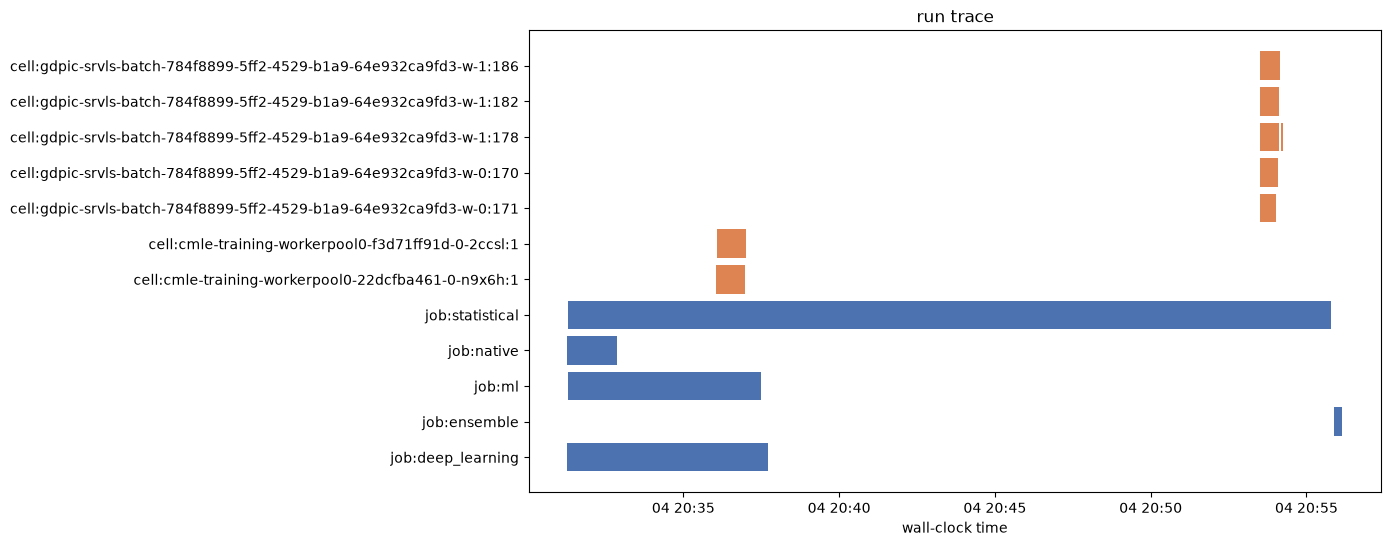

In [5]:
import matplotlib.pyplot as plt
from scale_forecasting import (
    plot_leaderboard,
    plot_metric_distribution,
    plot_trace,
)

display(forecaster.leaderboard_df())

review = forecaster.review_run()
plot_leaderboard(review)
plt.show()

plot_metric_distribution(review)
plt.show()

display(forecaster.cohorts_df())
display(forecaster.jobs_df())

forecaster.plot_calibration()
plt.show()

forecaster.plot_ensemble_weights()
plt.show()

forecaster.plot_forecasts(history_tail=120)
plt.show()

forecaster.plot_forecast_explanation(history_tail=120)
plt.show()

trace_df = forecaster.trace()
display(trace_df)
plot_trace(trace_df)
plt.show()